In [1]:
import math
import numpy as np
import chess
import torch
import torch.nn as nn
import torch.nn.functional as F

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [2]:


CKPT_PATH = "../weights/dual1.pth"


class ResBlock(nn.Module):
    def __init__(self, channels=128):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = self.bn2(self.conv2(x))
        x = F.relu(x + residual, inplace=True)
        return x


class ChessNet(nn.Module):
    def __init__(self, in_ch=19, filters=128, num_blocks=10, policy_dim=4672):
        super().__init__()
        self.input_conv = nn.Conv2d(in_ch, filters, 3, padding=1, bias=False)
        self.input_bn = nn.BatchNorm2d(filters)
        self.res_blocks = nn.Sequential(*[ResBlock(filters) for _ in range(num_blocks)])

        self.value_conv = nn.Conv2d(filters, 1, 1, bias=False)
        self.value_bn = nn.BatchNorm2d(1)
        self.value_fc1 = nn.Linear(64, 64)
        self.value_fc2 = nn.Linear(64, 1)

        self.policy_conv = nn.Conv2d(filters, 2, 1, bias=False)
        self.policy_bn = nn.BatchNorm2d(2)
        self.policy_fc = nn.Linear(2 * 8 * 8, policy_dim)

    def forward_features(self, x):
        x = F.relu(self.input_bn(self.input_conv(x)), inplace=True)
        x = self.res_blocks(x)
        return x

    def forward_raw(self, x, legal_mask=None):
        x = self.forward_features(x)

        v = F.relu(self.value_bn(self.value_conv(x)), inplace=True)
        v = v.view(v.size(0), -1)
        v = F.relu(self.value_fc1(v), inplace=True)
        v = self.value_fc2(v)

        p = F.relu(self.policy_bn(self.policy_conv(x)), inplace=True)
        p = p.view(p.size(0), -1)
        p = self.policy_fc(p)

        if legal_mask is not None:
            p = p.masked_fill(~legal_mask, float("-inf"))

        return v, p


def load_dual_model(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    state = ckpt["model_state"]

    in_ch = int(ckpt.get("input_channels", 19))
    filters = int(ckpt.get("filters", 128))
    num_blocks = int(ckpt.get("num_blocks", 10))
    policy_dim = int(ckpt.get("policy_dim", 4672))

    model = ChessNet(
        in_ch=in_ch,
        filters=filters,
        num_blocks=num_blocks,
        policy_dim=policy_dim,
    ).to(device)

    model.load_state_dict(state, strict=True)
    model.eval()
    return model


model = load_dual_model(CKPT_PATH, device)
model

ChessNet(
  (input_conv): Conv2d(19, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (input_bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (res_blocks): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True

In [3]:
squares_index = {
    'a':0, 'b':1, 'c':2, 'd':3,
    'e':4, 'f':5, 'g':6, 'h':7,
}

PIECE_ORDER = [
    chess.PAWN, chess.KNIGHT, chess.BISHOP,
    chess.ROOK, chess.QUEEN, chess.KING
]

def square_to_index(square):
    letter = chess.square_name(square)
    return 8 - int(letter[1]), squares_index[letter[0]]

def board_to_icpram_bitmap_plus(board, channels_first: bool = True) -> np.ndarray:
    planes = []

    # 12 piece planes, absolute color
    for color, sign in ((chess.WHITE, +1), (chess.BLACK, -1)):
        for pt in PIECE_ORDER:
            m = np.zeros((8, 8), dtype=np.float32)
            for sq in board.pieces(pt, color):
                r = 7 - chess.square_rank(sq)
                c = chess.square_file(sq)
                m[r, c] = sign
            planes.append(m)

    # castling rights
    wk = 1.0 if board.has_kingside_castling_rights(chess.WHITE) else 0.0
    wq = 1.0 if board.has_queenside_castling_rights(chess.WHITE) else 0.0
    bk = 1.0 if board.has_kingside_castling_rights(chess.BLACK) else 0.0
    bq = 1.0 if board.has_queenside_castling_rights(chess.BLACK) else 0.0

    planes.append(np.full((8, 8), wk, dtype=np.float32))
    planes.append(np.full((8, 8), wq, dtype=np.float32))
    planes.append(np.full((8, 8), bk, dtype=np.float32))
    planes.append(np.full((8, 8), bq, dtype=np.float32))

    # side to move
    stm = 1.0 if board.turn == chess.WHITE else -1.0
    planes.append(np.full((8, 8), stm, dtype=np.float32))

    # en passant
    ep = np.zeros((8, 8), dtype=np.float32)
    if board.ep_square is not None:
        r = 7 - chess.square_rank(board.ep_square)
        c = chess.square_file(board.ep_square)
        ep[r, c] = 1.0
    planes.append(ep)

    # 50-move rule
    halfmove = min(board.halfmove_clock, 100) / 100.0
    planes.append(np.full((8, 8), halfmove, dtype=np.float32))

    x = np.stack(planes, axis=0)   # (19,8,8)

    if not channels_first:
        x = np.transpose(x, (1, 2, 0))

    return x

In [4]:
def move_to_index(move: chess.Move) -> int:
    if move.promotion and move.promotion != chess.QUEEN:
        promo_offset = {
            chess.KNIGHT: 0,
            chess.BISHOP: 1,
            chess.ROOK: 2,
        }
        return 4096 + move.from_square * 3 + promo_offset[move.promotion]
    return move.from_square * 64 + move.to_square


def get_legal_mask(board: chess.Board) -> np.ndarray:
    mask = np.zeros(4672, dtype=np.bool_)
    for move in board.legal_moves:
        mask[move_to_index(move)] = True
    return mask

In [11]:
from collections import OrderedDict
import chess.polyglot

TT = OrderedDict()
TT_MAX_ITEMS = 500_000

def tt_get(key):
    v = TT.get(key)
    if v is not None:
        TT.move_to_end(key)
    return v

def tt_put(key, entry):
    old = TT.get(key)
    if old is not None:
        old_depth = old[0]
        new_depth = entry[0]
        if new_depth < old_depth:
            TT.move_to_end(key)
            return
    TT[key] = entry
    TT.move_to_end(key)
    if len(TT) > TT_MAX_ITEMS:
        TT.popitem(last=False)

INF = 1e9



In [12]:
import numpy as np
import chess
import torch
import math
import numpy as np
import chess
import chess.polyglot
import torch



@torch.inference_mode()
def eval_value_and_order(board: chess.Board):
    moves = list(board.legal_moves)
    if not moves:
        return 0.0, []

    x_np = board_to_icpram_bitmap_plus(board)  # (19,8,8)
    x = torch.from_numpy(x_np).unsqueeze(0).to(
        device=device, dtype=torch.float32, non_blocking=True
    )

    legal_mask_np = get_legal_mask(board)
    legal_mask = torch.from_numpy(legal_mask_np).unsqueeze(0).to(device)

    v_raw, p_logits = model.forward_raw(x, legal_mask)

    # value head: sigmoid -> cp-like inverse
    p = torch.sigmoid(v_raw).item()
    eps = 1e-6
    p = min(max(p, eps), 1.0 - eps)
    cp = 400.0 * math.log(p / (1.0 - p))

    # policy head: use logits to order legal moves
    logits = p_logits[0].detach().cpu().numpy()
    moves.sort(key=lambda mv: float(logits[move_to_index(mv)]), reverse=True)

    return float(cp), moves


def minimax(board: chess.Board, depth: int, alpha: float, beta: float) -> float:
    key = chess.polyglot.zobrist_hash(board)

    entry = tt_get(key)
    if entry is not None:
        tt_depth, tt_flag, tt_val, tt_moves = entry

        if depth == 0:
            return tt_val

        if tt_depth >= depth:
            if tt_flag == "EXACT":
                return tt_val
            if tt_flag == "LOWER":
                alpha = max(alpha, tt_val)
            elif tt_flag == "UPPER":
                beta = min(beta, tt_val)
            if beta <= alpha:
                return tt_val

        moves = tt_moves
    else:
        tt_val, moves = eval_value_and_order(board)
        tt_put(key, (0, "EXACT", float(tt_val), moves))

    if depth == 0 or board.is_game_over():
        return float(tt_val)

    alpha0, beta0 = alpha, beta
    push, pop = board.push, board.pop
    mm = minimax

    if board.turn == chess.WHITE:
        best = -np.inf
        for move in moves:
            push(move)
            v = mm(board, depth - 1, alpha, beta)
            pop()

            if v > best:
                best = v
            if v > alpha:
                alpha = v
            if beta <= alpha:
                break
    else:
        best = np.inf
        for move in moves:
            push(move)
            v = mm(board, depth - 1, alpha, beta)
            pop()

            if v < best:
                best = v
            if v < beta:
                beta = v
            if beta <= alpha:
                break

    if best <= alpha0:
        flag = "UPPER"
    elif best >= beta0:
        flag = "LOWER"
    else:
        flag = "EXACT"

    tt_put(key, (depth, flag, float(best), moves))
    return float(best)


def get_ai_move(board: chess.Board, depth: int):
    if board.is_game_over():
        return None

    key = chess.polyglot.zobrist_hash(board)
    entry = tt_get(key)

    if entry is not None:
        _, _, _, moves = entry
    else:
        _, moves = eval_value_and_order(board)
        tt_put(key, (0, "EXACT", 0.0, moves))

    if not moves:
        return None

    push, pop = board.push, board.pop
    mm = minimax

    alpha, beta = -np.inf, np.inf
    best_move = None

    if board.turn == chess.WHITE:
        best_val = -np.inf
        for move in moves:
            push(move)
            v = mm(board, depth - 1, alpha, beta)
            pop()

            if v > best_val:
                best_val = v
                best_move = move
            if best_val > alpha:
                alpha = best_val
    else:
        best_val = np.inf
        for move in moves:
            push(move)
            v = mm(board, depth - 1, alpha, beta)
            pop()

            if v < best_val:
                best_val = v
                best_move = move
            if best_val < beta:
                beta = best_val

    return best_move

In [7]:
#Generate openings database, DON'T RUN EVERYTIME YOU FUCKING IDIOT
# import numpy as np

# def process_games_to_npz(input_file, output_file):
#     with open(input_file, 'r') as file:
#         games_data = file.read()

#     games = games_data.split('\n')
#     all_games_moves = []

#     total_games = len(games)
#     print(f"Total games to process: {total_games}")

#     for index, game in enumerate(games):
#         moves = game.split(' ')
#         all_games_moves.append(moves[:-1])
        
#         if (index + 1) % 100 == 0 or index + 1 == total_games:
#             print(f"Processed {index + 1} of {total_games} games...")

#     np_positions = np.array(all_games_moves, dtype=object)
    
#     np.savez_compressed(output_file, positions=np_positions)
#     print("Processing complete. Data saved to", output_file)

# input_file = "../../n1/.ipynb_checkpoints/eval/Games.txt"
# output_file = "Games.npz"
# process_games_to_npz(input_file, output_file)

In [8]:
import numpy as np
import random

class ChessDatabase:
    def __init__(self, npz_file):
        # Load the data from the npz file at initialization
        data = np.load(npz_file, allow_pickle=True)
        self.positions = data['positions'].tolist()  # Convert to list for easier manipulation

    def select_move(self, current_position):
        # Prepare to store possible moves from the given position
        possible_moves = []
        positions_to_remove = []

        # Check each game for the given position and collect all possible moves that can follow
        for index, game in enumerate(self.positions):
            try:
                if game[:len(current_position)] == current_position:
                    possible_moves.append(game[len(current_position)])
                else:
                    positions_to_remove.append(index)
            except:
                positions_to_remove.append(index)

        for index in sorted(positions_to_remove, reverse=True):
            del self.positions[index]

        if possible_moves:
            selected_move = random.choice(possible_moves)
            return selected_move
        else:
            return None

# Example usage
db = ChessDatabase("Games.npz")


In [9]:
def convert_to_san(board, move_str):
    print(len(move_str), move_str)
    if len(move_str) == 5:
        #for promotions which are written e2e1Q and we turn into e1Q
        return move_str[2:]
    # Parse the from and to squares
    from_square = chess.parse_square(move_str[:2])
    to_square = chess.parse_square(move_str[2:])

    # Create a move object from the from and to squares
    move = chess.Move(from_square, to_square)
    return board.san(move)


In [31]:
TT.clear()
board = chess.Board()
db = ChessDatabase("Games.npz")
import chess.engine
i = 0
moves = []


my AI, ahh
g2f3
4 g2f3
['d4', 'Nf6', 'c4', 'e6', 'Nc3', 'Bb4', 'Nf3', 'c5', 'g3', 'O-O', 'Bg2', 'd5', 'Qd3', 'Nc6', 'Ng5', 'cxd4', 'h4', 'dxc4', 'Qxh7+', 'Nxh7', 'Ne4', 'dxc3', 'O-O', 'Nd4', 'Bg5', 'Qa5', 'Bd8', 'Nxe2+', 'Kh2', 'Qxd8', 'bxc3', 'Bxc3', 'Bf3']
32


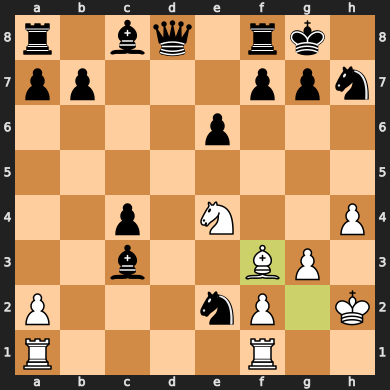

In [64]:
if i%2 == 0:
    print('my AI, ahh')
    move = db.select_move(moves)
    if move:
        moves.append(move)
        board.push_san(move)
    else:
        move = get_ai_move(board, 4)
        print(move)
        moves.append(convert_to_san(board, str(move)))
        board.push(move)
    
else:
    with chess.engine.SimpleEngine.popen_uci('../../n1/.ipynb_checkpoints/eval/stockfish/stockfish/stockfish-windows-x86-64-avx2.exe') as sf:
        info = sf.play(board, chess.engine.Limit(depth=10))
        moves.append(convert_to_san(board, str(info.move)))
        board.push(info.move)
        print(str(info.move))
        
print(moves)
        
i += 1
print(i-1)  
board

In [97]:
TT.clear()

In [98]:
pos = chess.Board('rn3rk1/pp2bppp/q3bn2/6R1/4P3/1PN3PP/P1Q2PB1/R1B3K1 w - - 3 17')
for i in range(1, 6):
    print(get_ai_move(pos, i))

g5g7
g5g7
g5g7
g5g7
g5g7


In [91]:
b2.fen()

'rnb2rk1/pp2bppp/q4n2/3R4/4P3/1PN3PP/P1Q2PB1/R1B3K1 w - - 1 16'

In [89]:
b2.pop()

Move.from_uci('d5g5')

In [93]:
board.push_san('Rg5')

Move.from_uci('d5g5')

In [63]:
b1 = chess.Board('rnb2rk1/pp2bppp/4pn2/3P4/3q4/6P1/PPQ1PPBP/RNB2RK1 w - - 0 10')
b2 = chess.Board('rnb2rk1/pp2bppp/1q2pn2/3p4/2PN4/6P1/PPQ1PPBP/RNBR2K1 b - - 2 9')
eval_board_cp(b1), eval_board_cp(b2)

(0.22283831238746643, 0.022871730849146843)

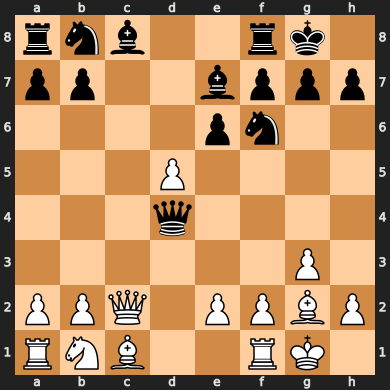

In [64]:
b1

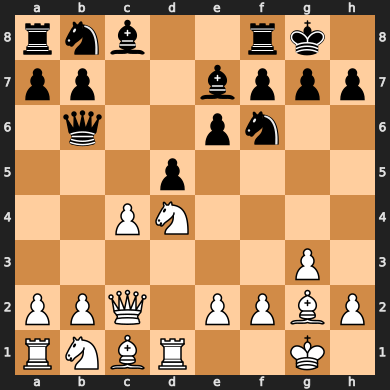

In [65]:
b2

In [181]:
TT.clear()
board = chess.Board()
db = ChessDatabase("Games.npz")
import chess.engine
i = 0
moves = []


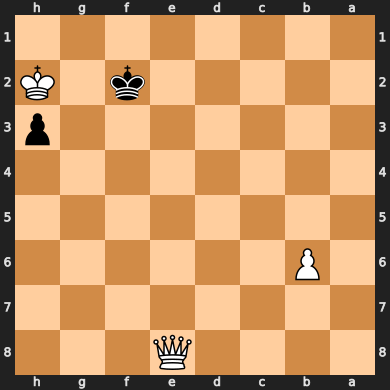

Your move.
To move: Black
Moves: ['d4', 'c6', 'c4', 'd5', 'Nf3', 'Bf5', 'Nc3', 'e6', 'cxd5', 'cxd5', 'Qa4+', 'Nc6', 'e4', 'dxe4', 'd5', 'exd5', 'Ne5', 'Qd6', 'Nxc6', 'bxc6', 'Bf4', 'Qd7', 'Nxd5', 'Qxd5', 'Bc4', 'Qc5', 'O-O', 'Nf6', 'Be3', 'Qd6', 'Rfd1', 'Qc7', 'Bf4', 'Qb6', 'Be3', 'Bc5', 'Bxc5', 'Qxc5', 'Rac1', 'Qb6', 'Qa3', 'Rd8', 'Bb3', 'Nd7', 'Rxc6', 'Qxc6', 'Ba4', 'Qc8', 'g4', 'Bxg4', 'f3', 'exf3', 'Re1+', 'Be6', 'Qd6', 'Qb8', 'Bxd7+', 'Rxd7', 'Qxb8+', 'Rd8', 'Qb5+', 'Ke7', 'Qg5+', 'Kd7', 'Qa5', 'Ra8', 'Qb5+', 'Ke7', 'Qb7+', 'Kf6', 'Qxf3+', 'Kg6', 'h4', 'h6', 'Qd3+', 'Bf5', 'h5+', 'Kg5', 'Re5', 'g6', 'hxg6', 'fxg6', 'Qg3+', 'Kf6', 'Rc5', 'Rac8', 'Qd6+', 'Kf7', 'Rc7+', 'Rxc7', 'Qxc7+', 'Ke6', 'Qxa7', 'Rc8', 'b4', 'Ke5', 'b5', 'Kf4', 'Qf2+', 'Kg4', 'Qe2+', 'Kg3', 'Qe3+', 'Kg4', 'a4', 'Ra8', 'Qd2', 'Rxa4', 'Qd1+', 'Kg5', 'Qxa4', 'Kf6', 'Qa7', 'h5', 'Qe3', 'h4', 'b6', 'h3', 'Kh2', 'Bc8', 'Qc5', 'Bb7', 'Qd6+', 'Kg5', 'Qe7+', 'Kh5', 'Qxb7', 'g5', 'Qh7+', 'Kg4', 'Qf7', 'Kh4', 'Qe8', 'g4',

In [ ]:
import chess
import chess.svg
from IPython.display import display, SVG, clear_output

HUMAN_COLOR = chess.BLACK   # set chess.WHITE if you play White

def draw(board, moves, status=""):
    clear_output(wait=True)
    flipped = (HUMAN_COLOR == chess.BLACK)   # fixed POV
    display(SVG(chess.svg.board(board=board, flipped=flipped)))
    if status:
        print(status)
    print("To move:", "White" if board.turn == chess.WHITE else "Black")
    print("Moves:", moves)

def push_db_or_engine(board, moves, db, depth=1):
    move_str = db.select_move(moves)

    if move_str:
        # try SAN
        try:
            mv = board.parse_san(move_str)
            san = board.san(mv)
            board.push(mv)
            moves.append(san)
            return
        except chess.IllegalMoveError:
            pass

        # try UCI
        try:
            mv = chess.Move.from_uci(move_str)
            if mv in board.legal_moves:
                san = board.san(mv)
                board.push(mv)
                moves.append(san)
                return
        except ValueError:
            pass

        # DB miss / mismatch; fall through to engine

    mv = get_ai_move(board, depth)  # must return chess.Move
    if mv not in board.legal_moves:
        raise ValueError(f"Engine returned illegal move {mv} in {board.fen()}")

    san = board.san(mv)
    board.push(mv)
    moves.append(san)

def get_user_move_with_retry(board):
    while True:
        s = input(">")
        try:
            mv = board.parse_san(s)
            san = board.san(mv)
            board.push(mv)
            return san
        except (chess.IllegalMoveError, chess.AmbiguousMoveError, ValueError) as e:
            print(f"Invalid move: {s} ({e}). Try again.")

# Main loop
while not board.is_game_over():
    if board.turn == HUMAN_COLOR:
        draw(board, moves, status="Your move.")
        san = get_user_move_with_retry(board)
        moves.append(san)
    else:
        draw(board, moves, status="AI thinking…")
        push_db_or_engine(board, moves, db, depth=4)

draw(board, moves, status=f"Game over: {board.result()}")


In [ ]:
'd4', 'c6', 'c4', 'd5', 'Nf3', 'Bf5', 'Nc3', 'e6', 'cxd5', 'cxd5', 'Qa4+', 'Nc6', 'e4', 'dxe4', 'd5', 'exd5', 'Ne5', 'Qd6', 'Nxc6', 'bxc6', 'Bf4', 'Qd7', 'Nxd5', 'Qxd5', 'Bc4', 'Qc5', 'O-O', 'Nf6', 'Be3', 'Qd6', 'Rfd1', 'Qc7', 'Bf4', 'Qb6', 'Be3', 'Bc5', 'Bxc5', 'Qxc5', 'Rac1', 'Qb6', 'Qa3', 'Rd8', 'Bb3', 'Nd7', 'Rxc6', 'Qxc6', 'Ba4', 'Qc8', 'g4', 'Bxg4', 'f3', 'exf3', 'Re1+', 'Be6', 'Qd6', 'Qb8', 'Bxd7+', 'Rxd7', 'Qxb8+', 'Rd8', 'Qb5+', 'Ke7', 'Qg5+', 'Kd7', 'Qa5', 'Ra8', 'Qb5+', 'Ke7', 'Qb7+', 'Kf6', 'Qxf3+', 'Kg6', 'h4', 'h6', 'Qd3+', 'Bf5', 'h5+', 'Kg5', 'Re5', 'g6', 'hxg6', 'fxg6', 'Qg3+', 'Kf6', 'Rc5', 'Rac8', 'Qd6+', 'Kf7', 'Rc7+', 'Rxc7', 'Qxc7+', 'Ke6', 'Qxa7', 'Rc8', 'b4', 'Ke5', 'b5', 'Kf4', 'Qf2+', 'Kg4', 'Qe2+', 'Kg3', 'Qe3+', 'Kg4', 'a4', 'Ra8', 'Qd2', 'Rxa4', 'Qd1+', 'Kg5', 'Qxa4', 'Kf6', 'Qa7', 'h5', 'Qe3', 'h4', 'b6', 'h3', 'Kh2', 'Bc8', 'Qc5', 'Bb7', 'Qd6+', 'Kg5', 'Qe7+', 'Kh5', 'Qxb7', 'g5', 'Qh7+', 'Kg4', 'Qf7', 'Kh4', 'Qe8', 'g4', 'Qe7+', 'Kh5', 'Qh7+', 'Kg5', 'Qg7+', 'Kh4', 'Qe7+', 'Kh5', 'Qh7+', 'Kg5', 'Qg7+', 'Kf4', 'Qh6+', 'Kf3', 'Qh5', 'Kf4', 'Qh6+', 'Kf3', 'Qh5', 'Kf2', 'Qxg4', 'Kf1', 'Qe6', 'Kf2', 'Qe8'

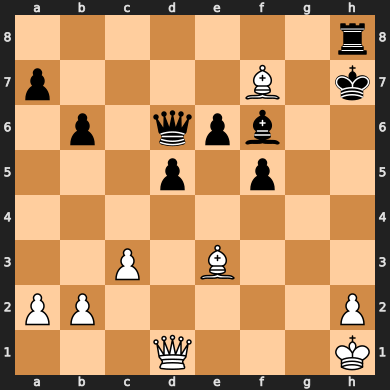

In [192]:
bb = chess.Board('7r/p4B1k/1p1qpb2/3p1p2/8/2P1B3/PP5P/3Q3K w - - 3 31')
bb

In [193]:
TT.clear()
for i in range(1, 6):
    print(get_ai_move(bb, i))

e3f4
d1h5
d1f3
d1h5
d1h5


In [15]:
'''
GAME 1

Your move.
To move: Black
Moves: ['e4', 'c6', 'd4', 'd5', 'exd5', 'cxd5', 'c4', 'Nf6', 'Nc3', 'Bg4', 'Qb3', 'Qd7', 'cxd5', 'g6', 'Bb5', 'Nc6', 'dxc6', 'bxc6', 'Bc4', 'e6', 'f3', 'Bf5', 'g4', 'Bxg4', 'Bg5', 'Qxd4', 'Nge2', 'Qe5', 'Bf4', 'Qc5', 'fxg4', 'Nxg4', 'O-O-O', 'Nf2', 'Qb7', 'Rd8', 'Rxd8+', 'Kxd8', 'Qb8+', 'Kd7', 'Qc7+', 'Ke8', 'Qc8+', 'Ke7', 'Qc7+', 'Kf6', 'Rf1', 'g5', 'Rxf2', 'Qxf2', 'Ne4+', 'Kg6', 'Nxf2', 'gxf4', 'Nxf4+', 'Kg7', 'Nxe6+', 'Kf6', 'Ne4+', 'Kg6', 'Nxf8+', 'Rxf8', 'Qxc6+', 'f6', 'Nc5', 'h6', 'Qe4+', 'f5', 'Qg2+', 'Kh7', 'Qd5', 'Kh8', 'Na6', 'Kh7', 'h3', 'Kh8', 'Qd4+', 'Kh7', 'h4', 'f4', 'h5', 'f3', 'Kb1', 'f2', 'Bd3+', 'Kg8', 'Qg4+', 'Kh8', 'Qd4+', 'Kg8', 'Qg4+', 'Kh8', 'Qd4+', 'Kg8', 'Qg4+', 'Kh8', 'Qd4+']


'''

"\nGAME 1\n\nYour move.\nTo move: Black\nMoves: ['e4', 'c6', 'd4', 'd5', 'exd5', 'cxd5', 'c4', 'Nf6', 'Nc3', 'Bg4', 'Qb3', 'Qd7', 'cxd5', 'g6', 'Bb5', 'Nc6', 'dxc6', 'bxc6', 'Bc4', 'e6', 'f3', 'Bf5', 'g4', 'Bxg4', 'Bg5', 'Qxd4', 'Nge2', 'Qe5', 'Bf4', 'Qc5', 'fxg4', 'Nxg4', 'O-O-O', 'Nf2', 'Qb7', 'Rd8', 'Rxd8+', 'Kxd8', 'Qb8+', 'Kd7', 'Qc7+', 'Ke8', 'Qc8+', 'Ke7', 'Qc7+', 'Kf6', 'Rf1', 'g5', 'Rxf2', 'Qxf2', 'Ne4+', 'Kg6', 'Nxf2', 'gxf4', 'Nxf4+', 'Kg7', 'Nxe6+', 'Kf6', 'Ne4+', 'Kg6', 'Nxf8+', 'Rxf8', 'Qxc6+', 'f6', 'Nc5', 'h6', 'Qe4+', 'f5', 'Qg2+', 'Kh7', 'Qd5', 'Kh8', 'Na6', 'Kh7', 'h3', 'Kh8', 'Qd4+', 'Kh7', 'h4', 'f4', 'h5', 'f3', 'Kb1', 'f2', 'Bd3+', 'Kg8', 'Qg4+', 'Kh8', 'Qd4+', 'Kg8', 'Qg4+', 'Kh8', 'Qd4+', 'Kg8', 'Qg4+', 'Kh8', 'Qd4+']\n\n\n"

In [16]:
'''
Game 2
[Event "Analysis"]
[Site "Online"]
[Result "0-1"]

1. e4 c6 2. Nf3 d5 3. Nc3 dxe4 4. Nxe4 Nf6 5. Qe2 Nxe4 6. Qxe4 Nd7 7. d4 Nf6 8. Qe5 Bg4 9. c3 e6 10. Qe2 Bd6 11. g3 O-O 12. Bg2 Qc7 13. O-O e5 14. dxe5 Bxf3 15. Bxf3 Bxe5 16. Re1 Rfe8 17. Be3 Rad8 18. Qc4 Nd5 19. Bxd5 Rxd5 20. a4 Re6 21. Bxa7 b6 22. a5 Qxa7 23. axb6 Qxb6 24. Qxd5 cxd5 25. Ra8+ Bb8 26. Rxe6 fxe6 27. b4 Kf7 28. Ra1 Ba7 29. Ra2 d4 30. Rd2 dxc3 31. Rd3 Qxf2+ 32. Kh1 Qf1# 0-1

'''

'\nGame 2\n[Event "Analysis"]\n[Site "Online"]\n[Result "0-1"]\n\n1. e4 c6 2. Nf3 d5 3. Nc3 dxe4 4. Nxe4 Nf6 5. Qe2 Nxe4 6. Qxe4 Nd7 7. d4 Nf6 8. Qe5 Bg4 9. c3 e6 10. Qe2 Bd6 11. g3 O-O 12. Bg2 Qc7 13. O-O e5 14. dxe5 Bxf3 15. Bxf3 Bxe5 16. Re1 Rfe8 17. Be3 Rad8 18. Qc4 Nd5 19. Bxd5 Rxd5 20. a4 Re6 21. Bxa7 b6 22. a5 Qxa7 23. axb6 Qxb6 24. Qxd5 cxd5 25. Ra8+ Bb8 26. Rxe6 fxe6 27. b4 Kf7 28. Ra1 Ba7 29. Ra2 d4 30. Rd2 dxc3 31. Rd3 Qxf2+ 32. Kh1 Qf1# 0-1\n\n'

In [14]:
b1 = chess.Board('r1b1kbnr/1pp1pppp/p1n5/3N4/8/8/PPPP1PPP/R1BQKBNR w KQkq - 0 1')
b2 = chess.Board('r1bqkbnr/pppp1ppp/8/8/8/P1nKP3/2P2PPP/1RB2BNR b KQkq - 0 1')

eval_board_cp(b1), eval_board_cp(b2)

(1.0058956146240234, -1.0171650648117065)

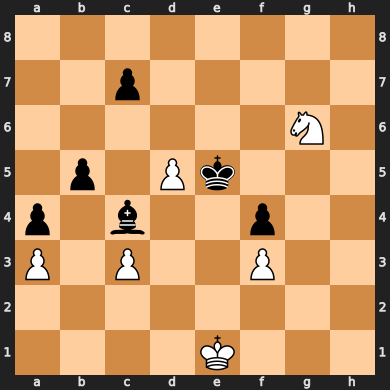

Game over: 1/2-1/2
To move: Black
Moves: ['d4', 'd5', 'c4', 'dxc4', 'Nc3', 'e5', 'Nf3', 'exd4', 'Nxd4', 'Nc6', 'e3', 'Nxd4', 'exd4', 'Nf6', 'Bxc4', 'Be7', 'O-O', 'O-O', 'Re1', 'Bd6', 'Bg5', 'h6', 'Bh4', 'g5', 'Bg3', 'Bxg3', 'hxg3', 'Re8', 'Rxe8+', 'Qxe8', 'Qd2', 'Qd8', 'd5', 'Ne8', 'Re1', 'Nd6', 'Bb3', 'Bf5', 'f3', 'Qf6', 'g4', 'Bg6', 'Re2', 'Kg7', 'Re1', 'Rh8', 'Nd1', 'h5', 'Nf2', 'a6', 'a3', 'b5', 'Ba2', 'a5', 'Qc1', 'hxg4', 'Nxg4', 'Qd4+', 'Ne3', 'Re8', 'Qc3', 'Qxc3', 'bxc3', 'f5', 'g3', 'f4', 'gxf4', 'gxf4', 'Ng2', 'Rxe1+', 'Nxe1', 'Kf6', 'Ng2', 'Ke5', 'Kf1', 'Bd3+', 'Ke1', 'a4', 'Nh4', 'Nc4', 'Bxc4', 'Bxc4', 'Ng6+', 'Kf5', 'Ne7+', 'Ke5', 'Ng6+', 'Kf5', 'Ne7+', 'Ke5', 'Ng6+', 'Kf5', 'Ne7+', 'Ke5', 'Ng6+', 'Kf5', 'Ne7+', 'Ke5', 'Ng6+']


In [177]:
import chess
import chess.svg
from IPython.display import display, SVG, clear_output
import time

ENGINE_DEPTH_WHITE = 4
ENGINE_DEPTH_BLACK = 4

def draw(board, moves, status=""):
    clear_output(wait=True)
    display(SVG(chess.svg.board(board=board)))
    if status:
        print(status)
    print("To move:", "White" if board.turn == chess.WHITE else "Black")
    print("Moves:", moves)

def push_engine(board, moves, depth):
    mv = get_ai_move(board, depth)
    if mv not in board.legal_moves:
        raise ValueError(f"Engine returned illegal move {mv} in {board.fen()}")

    san = board.san(mv)
    board.push(mv)
    moves.append(san)

# ---- SELF PLAY ----
board = chess.Board()
moves = []

while not board.is_game_over():
    if board.turn == chess.WHITE:
        draw(board, moves, status="White thinking…")
        push_engine(board, moves, ENGINE_DEPTH_WHITE)
    else:
        draw(board, moves, status="Black thinking…")
        push_engine(board, moves, ENGINE_DEPTH_BLACK)

draw(board, moves, status=f"Game over: {board.result()}")

In [178]:
moves

['d4',
 'd5',
 'c4',
 'dxc4',
 'Nc3',
 'e5',
 'Nf3',
 'exd4',
 'Nxd4',
 'Nc6',
 'e3',
 'Nxd4',
 'exd4',
 'Nf6',
 'Bxc4',
 'Be7',
 'O-O',
 'O-O',
 'Re1',
 'Bd6',
 'Bg5',
 'h6',
 'Bh4',
 'g5',
 'Bg3',
 'Bxg3',
 'hxg3',
 'Re8',
 'Rxe8+',
 'Qxe8',
 'Qd2',
 'Qd8',
 'd5',
 'Ne8',
 'Re1',
 'Nd6',
 'Bb3',
 'Bf5',
 'f3',
 'Qf6',
 'g4',
 'Bg6',
 'Re2',
 'Kg7',
 'Re1',
 'Rh8',
 'Nd1',
 'h5',
 'Nf2',
 'a6',
 'a3',
 'b5',
 'Ba2',
 'a5',
 'Qc1',
 'hxg4',
 'Nxg4',
 'Qd4+',
 'Ne3',
 'Re8',
 'Qc3',
 'Qxc3',
 'bxc3',
 'f5',
 'g3',
 'f4',
 'gxf4',
 'gxf4',
 'Ng2',
 'Rxe1+',
 'Nxe1',
 'Kf6',
 'Ng2',
 'Ke5',
 'Kf1',
 'Bd3+',
 'Ke1',
 'a4',
 'Nh4',
 'Nc4',
 'Bxc4',
 'Bxc4',
 'Ng6+',
 'Kf5',
 'Ne7+',
 'Ke5',
 'Ng6+',
 'Kf5',
 'Ne7+',
 'Ke5',
 'Ng6+',
 'Kf5',
 'Ne7+',
 'Ke5',
 'Ng6+',
 'Kf5',
 'Ne7+',
 'Ke5',
 'Ng6+']

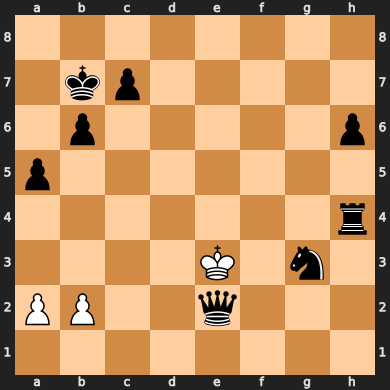

Game over: 0-1
To move: White
Moves: e4 e5 Nf3 Nc6 Bc4 Nf6 Ng5 d5 exd5 Na5 Bf1 h6 Nf3 e4 Ng1 Qxd5 Nc3 Qe5 Qe2 Nc6 Qb5 Bc5 d4 exd3+ Be3 Bxe3 Qxe5+ Nxe5 fxe3 dxc2 Nf3 Nfg4 Rc1 Nxf3+ gxf3 Nxe3 Bd3 Bf5 Bxf5 Nxf5 Rxc2 O-O-O Kf2 Nd4 Rd2 Nf5 Rhd1 Rxd2+ Rxd2 g6 Nb5 a6 Nc3 Rd8 Rc2 b6 Ne4 Kb7 Ng3 Nd4 Rc1 Ne6 Ke1 f5 h4 Rd3 Rc3 Rd5 Ne2 Rd8 Ng3 a5 h5 f4 Ne4 gxh5 Rc2 Nd4 Rc3 Nf5 Rc1 Rd4 Nc3 h4 Ne2 Rd3 Nxf4 Rxf3 Rb1 Rxf4 Ke2 h3 Rh1 Ng3+ Ke3 Rh4 Ra1 h2 Rg1 hxg1=Q+ Kd2 Qg2+ Ke3 Qe2#
Saved 1 games to: deep_vs_stockfish.pgn


In [14]:
import random
import time
import chess
import chess.svg
import chess.pgn
import chess.engine
from IPython.display import display, SVG, clear_output

# -----------------------------
# CONFIG
STOCKFISH_PATH = r"../../n1/.ipynb_checkpoints/eval/stockfish/stockfish/stockfish-windows-x86-64-avx2.exe"

N_GAMES = 1
MY_AI_COLOR = chess.WHITE          # set chess.BLACK if you want your AI to be Black
ENGINE_DEPTH_STOCKFISH = 10
ENGINE_DEPTH_MYAI = 4

# randomness for your AI (pick one of the two modes below)
EPSILON_RANDOM = 0.10              # with prob eps, play a random legal move (simple + effective)
TOPK_RANDOM = 0                    # if >0 and you provide eval_fn, sample among top-K moves (better)

MAX_PLIES = 150                    # safety
SHOW_BOARD = True
PAUSE_SEC = 0.15
FLIP_BOARD = False                 # True => show from Black POV (bottom = Black)

OUT_PGN_PATH = "deep_vs_stockfish.pgn"
SEED = 0

# -----------------------------
# YOU MUST HAVE THIS (as you already do)
# def get_ai_move(board, depth) -> chess.Move: ...

# Optional: if you have a fast evaluation for a position after pushing a move, implement this.
# If you DON'T have it, leave as None and we'll just use EPSILON_RANDOM.
eval_fn = None
# Example signature if you wire it later:
# def eval_fn(board: chess.Board) -> float:
#     """Higher is better for side-to-move (or pick a consistent convention)."""
#     ...

# -----------------------------
def draw(board, moves_san, status=""):
    clear_output(wait=True)
    display(SVG(chess.svg.board(board=board, flipped=FLIP_BOARD)))
    if status:
        print(status)
    print("To move:", "White" if board.turn == chess.WHITE else "Black")
    print("Moves:", " ".join(moves_san))

def choose_my_ai_move(board: chess.Board, depth: int) -> chess.Move:
    # Mode A: epsilon-random over legal moves (works even if your AI is fully deterministic)
    if EPSILON_RANDOM > 0 and random.random() < EPSILON_RANDOM:
        return random.choice(list(board.legal_moves))

    # Mode B (better): sample among top-K moves using eval_fn if provided
    if TOPK_RANDOM and eval_fn is not None:
        scored = []
        for mv in board.legal_moves:
            board.push(mv)
            s = float(eval_fn(board))
            board.pop()
            scored.append((s, mv))
        scored.sort(key=lambda x: x[0], reverse=True)
        k = min(TOPK_RANDOM, len(scored))
        top = scored[:k]
        # soft-ish sampling: bias toward best but allow variety
        weights = [1.0 / (i + 1) for i in range(k)]
        return random.choices([mv for _, mv in top], weights=weights, k=1)[0]

    # Default: your deterministic move
    mv = get_ai_move(board, depth)
    if mv not in board.legal_moves:
        raise ValueError(f"MyAI returned illegal move {mv} in {board.fen()}")
    return mv

def choose_stockfish_move(sf: chess.engine.SimpleEngine, board: chess.Board, depth: int) -> chess.Move:
    info = sf.play(board, chess.engine.Limit(depth=depth))
    mv = info.move
    if mv not in board.legal_moves:
        raise ValueError(f"Stockfish returned illegal move {mv} in {board.fen()}")
    return mv

def play_one_game(sf: chess.engine.SimpleEngine, game_idx: int) -> chess.pgn.Game:
    board = chess.Board()
    moves_san = []

    game = chess.pgn.Game()
    game.headers["Event"] = "MyAI vs Stockfish"
    game.headers["Site"] = "Jupyter"
    game.headers["Round"] = str(game_idx + 1)
    game.headers["White"] = "MyAI" if MY_AI_COLOR == chess.WHITE else "Stockfish"
    game.headers["Black"] = "Stockfish" if MY_AI_COLOR == chess.WHITE else "MyAI"

    node = game

    ply = 0
    while not board.is_game_over() and ply < MAX_PLIES:
        is_my_ai_turn = (board.turn == MY_AI_COLOR)

        if SHOW_BOARD:
            draw(board, moves_san, status=("MyAI thinking…" if is_my_ai_turn else "Stockfish thinking…"))

        if is_my_ai_turn:
            mv = choose_my_ai_move(board, ENGINE_DEPTH_MYAI)
        else:
            mv = choose_stockfish_move(sf, board, ENGINE_DEPTH_STOCKFISH)

        san = board.san(mv)     # compute BEFORE push
        board.push(mv)
        moves_san.append(san)

        node = node.add_variation(mv)
        ply += 1

        if SHOW_BOARD and PAUSE_SEC:
            time.sleep(PAUSE_SEC)

    if SHOW_BOARD:
        draw(board, moves_san, status=f"Game over: {board.result()}")

    game.headers["Result"] = board.result()
    return game

def run_match_and_save():
    random.seed(SEED)

    games = []
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as sf:
        for gi in range(N_GAMES):
            games.append(play_one_game(sf, gi))

    with open(OUT_PGN_PATH, "w", encoding="utf-8") as f:
        for g in games:
            print(g, file=f)
            print("", file=f)  # blank line between games

    print(f"Saved {len(games)} games to: {OUT_PGN_PATH}")

run_match_and_save()


In [ ]:
'''
depth 2 vs 2

[Event "Analysis"]
[Site "Online"]
[Result "1/2-1/2"]

1. e4 Nf6 2. e5 Ne4 3. d3 Nc5 4. d4 Na4 5. c4 Nb6 6. c5 Nd5 7. Bc4 e6 8. a3 Nc6 9. Ne2 b6 10. Bxd5 exd5 11. Nbc3 Ba6 12. Be3 Bxe2 13. Qxe2 Ne7 14. Qd3 bxc5 15. dxc5 c6 16. Bg5 Qb8 17. O-O Qb3 18. Rfb1 Qb7 19. b4 Ng6 20. a4 h6 21. Be3 Be7 22. f4 O-O 23. Ne2 Qc8 24. b5 Rb8 25. Ra2 Re8 26. Bd4 Nf8 27. f5 Bh4 28. Rab2 Rb7 29. b6 axb6 30. cxb6 d6 31. exd6 Nd7 32. a5 Bf6 33. Bxf6 Nxf6 34. a6 Rb8 35. b7 Qd7 36. Qg3 Ne4 37. Qf4 Nxd6 38. Ng3 c5 39. f6 Kh7 40. fxg7 d4 41. Rf1 d3 42. Rb6 Qc7 43. g8=Q+ Kxg8 44. Rxd6 Qb6 45. Qxf7+ Kh8 46. Qf6+ Kh7 47. Qxh6+ Kg8 48. Rg6+ Qxg6 49. Qxg6+ Kh8 50. Qh6+ Kg8 51. Qg6+ Kh8 52. Qh6+ Kg8 53. Qg6+ Kh8 54. Qh6+ Kg8 55. Qg6+ Kh8 56. Qh6+ Kg8 57. Qg6+ 1/2-1/2
'''

In [24]:
# ============================================================
# NEW vs OLD live match (single paste block)
# Assumes you ALREADY defined elsewhere in your notebook:
#   - device
#   - board_to_icpram_bitmap_plus(board) -> np (17,8,8)
#   - ordered_moves(board) -> list[chess.Move]
#   - class CNN (old) and class CNNn (new ResNet)
# ============================================================

import time
from collections import OrderedDict
from IPython.display import display, SVG, clear_output
import chess, chess.svg, chess.pgn, chess.polyglot
import numpy as np
import torch
import torch.nn.functional as F

# ---------- CONFIG ----------
OLD_CKPT = "../weights/option2_newCNN.pth"
NEW_CKPT = "../weights/option3_newResLayer.pth"

NEW_IS_WHITE = True     # True => NEW plays White, OLD plays Black. False swaps.
DEPTH_OLD = 5
DEPTH_NEW = 5

DB_PLIES = 0           # set 0 to disable opening DB
SLEEP_SEC = 0.05        # slow down display; 0.0 for fastest

# optional: if you already have db = ChessDatabase("Games.npz"), keep it.
# otherwise set db = None
try:
    db
except NameError:
    db = None

# ---------- LOADERS ----------
def load_old_CNN(CNN_class, ckpt_path, device, strict=True,
                 default_in_ch=17,
                 default_conv_channels=(192,192,192,192),
                 default_fc_hidden=(256,),
                 default_p_drop=0.1):
    p = torch.load(ckpt_path, map_location="cpu")
    state = p["model_state"] if isinstance(p, dict) and "model_state" in p else p
    cfg = (p.get("model_cfg", {}) if isinstance(p, dict) else {}) or {}

    in_ch = cfg.get("in_ch") or (p.get("input_dim") if isinstance(p, dict) else None) or default_in_ch
    conv_channels = cfg.get("conv_channels") or (p.get("conv_channels") if isinstance(p, dict) else None) or default_conv_channels
    fc_hidden = cfg.get("fc_hidden") or (p.get("arch") if isinstance(p, dict) else None) or default_fc_hidden
    p_drop = cfg.get("p_drop") or (p.get("p_drop") if isinstance(p, dict) else None) or default_p_drop

    model = CNN_class(int(in_ch), tuple(conv_channels), tuple(fc_hidden), float(p_drop)).to(device)
    model.load_state_dict(state, strict=strict)
    model.eval()
    return model

def load_new_CNNn(CNNn_class, ckpt_path, device, strict=False,
                  default_in_ch=17,
                  default_trunk_ch=192,
                  default_n_blocks=8,
                  default_fc_hidden=(256,),
                  default_p_drop=0.1):
    p = torch.load(ckpt_path, map_location="cpu")
    state = p["model_state"] if isinstance(p, dict) and "model_state" in p else p
    cfg = (p.get("model_cfg", {}) if isinstance(p, dict) else {}) or {}

    in_ch = cfg.get("in_ch") or (p.get("input_dim") if isinstance(p, dict) else None) or default_in_ch
    trunk_ch = cfg.get("trunk_ch") or (p.get("trunk_ch") if isinstance(p, dict) else None)
    n_blocks = cfg.get("n_blocks") or (p.get("n_blocks") if isinstance(p, dict) else None)

    conv_channels = cfg.get("conv_channels") or (p.get("conv_channels") if isinstance(p, dict) else None)
    if trunk_ch is None and conv_channels is not None:
        trunk_ch = int(tuple(conv_channels)[0])

    if trunk_ch is None: trunk_ch = default_trunk_ch
    if n_blocks is None: n_blocks = default_n_blocks

    fc_hidden = cfg.get("fc_hidden") or (p.get("arch") if isinstance(p, dict) else None) or default_fc_hidden
    p_drop = cfg.get("p_drop") or (p.get("p_drop") if isinstance(p, dict) else None) or default_p_drop

    model = CNNn_class(int(in_ch), trunk_ch=int(trunk_ch), n_blocks=int(n_blocks),
                       fc_hidden=tuple(fc_hidden), p_drop=float(p_drop)).to(device)
    model.load_state_dict(state, strict=strict)
    model.eval()
    return model

model_old = load_old_CNN(CNN,  OLD_CKPT, device, strict=True)
model_new = load_new_CNNn(CNNn, NEW_CKPT, device, strict=False)

# ---------- SEARCH (separate TT per side) ----------
TT_MAX = 500_000
TT_old = OrderedDict()
TT_new = OrderedDict()

def tt_get(TT, key):
    v = TT.get(key)
    if v is not None:
        TT.move_to_end(key)
    return v

def tt_put(TT, key, entry):
    old = TT.get(key)
    if old is not None and entry[0] < old[0]:
        TT.move_to_end(key)
        return
    TT[key] = entry
    TT.move_to_end(key)
    if len(TT) > TT_MAX:
        TT.popitem(last=False)

@torch.inference_mode()
def eval_with(model, board: chess.Board) -> float:
    x_np = board_to_icpram_bitmap_plus(board)  # (17,8,8)
    x = torch.from_numpy(x_np).unsqueeze(0).float().to(device, non_blocking=True)
    return float(model(x).item())

def make_minimax(model, TT):
    def minimax(board: chess.Board, depth: int, alpha: float, beta: float) -> float:
        key = chess.polyglot.zobrist_hash(board)

        entry = tt_get(TT, key)
        if entry is not None:
            d0, flag, val = entry
            if d0 >= depth:
                if flag == "EXACT": return val
                if flag == "LOWER": alpha = max(alpha, val)
                if flag == "UPPER": beta  = min(beta, val)
                if beta <= alpha: return val

        if depth == 0 or board.is_game_over(claim_draw=True):
            v = eval_with(model, board)
            tt_put(TT, key, (depth, "EXACT", v))
            return v

        a0, b0 = alpha, beta
        push, pop = board.push, board.pop

        if board.turn == chess.WHITE:
            best = -np.inf
            for mv in ordered_moves(board):
                push(mv)
                v = minimax(board, depth-1, alpha, beta)
                pop()
                if v > best: best = v
                if v > alpha: alpha = v
                if beta <= alpha: break
        else:
            best = np.inf
            for mv in ordered_moves(board):
                push(mv)
                v = minimax(board, depth-1, alpha, beta)
                pop()
                if v < best: best = v
                if v < beta: beta = v
                if beta <= alpha: break

        flag = "EXACT"
        if best <= a0: flag = "UPPER"
        elif best >= b0: flag = "LOWER"
        tt_put(TT, key, (depth, flag, float(best)))
        return float(best)
    return minimax

minimax_old = make_minimax(model_old, TT_old)
minimax_new = make_minimax(model_new, TT_new)

def pick_move(minimax_fn, board: chess.Board, depth: int):
    moves = ordered_moves(board)
    if not moves:
        return None
    push, pop = board.push, board.pop
    alpha, beta = -np.inf, np.inf
    best_mv = None

    if board.turn == chess.WHITE:
        best = -np.inf
        for mv in moves:
            push(mv)
            v = minimax_fn(board, depth-1, alpha, beta)
            pop()
            if v > best:
                best = v
                best_mv = mv
            alpha = max(alpha, best)
    else:
        best = np.inf
        for mv in moves:
            push(mv)
            v = minimax_fn(board, depth-1, alpha, beta)
            pop()
            if v < best:
                best = v
                best_mv = mv
            beta = min(beta, best)

    return best_mv

# ---------- OPTIONAL OPENING DB ----------
def try_db_move(board, san_moves):
    if db is None:
        return None
    ms = db.select_move(san_moves)
    if not ms:
        return None
    try:
        mv = board.parse_san(ms)
        if mv in board.legal_moves:
            return mv
    except Exception:
        pass
    try:
        mv = chess.Move.from_uci(ms)
        if mv in board.legal_moves:
            return mv
    except Exception:
        pass
    return None

# ---------- LIVE GAME ----------
board = chess.Board()
board.push_san('e4')
san_moves = ['e4']

white_name = f"NEW(d={DEPTH_NEW})" if NEW_IS_WHITE else f"OLD(d={DEPTH_OLD})"
black_name = f"OLD(d={DEPTH_OLD})" if NEW_IS_WHITE else f"NEW(d={DEPTH_NEW})"

TT_old.clear(); TT_new.clear()

# while not board.is_game_over(claim_draw=True):
#     is_white = (board.turn == chess.WHITE)

#     if is_white:
#         mover = white_name
#         mm = minimax_new if NEW_IS_WHITE else minimax_old
#         depth = DEPTH_NEW if NEW_IS_WHITE else DEPTH_OLD
#     else:
#         mover = black_name
#         mm = minimax_old if NEW_IS_WHITE else minimax_new
#         depth = DEPTH_OLD if NEW_IS_WHITE else DEPTH_NEW

#     use_db = (db is not None) and (DB_PLIES > 0) and (board.ply() < DB_PLIES)

#     clear_output(wait=True)
#     display(SVG(chess.svg.board(board=board)))
#     print(f"To move: {'White' if is_white else 'Black'} | Thinking: {mover} | depth={depth} | db={use_db} | ply={board.ply()}")
#     if san_moves:
#         print("Moves:", " ".join(san_moves[-40:]))

#     mv = try_db_move(board, san_moves) if use_db else None
#     src = "DB" if mv is not None else "NN"
#     if mv is None:
#         mv = pick_move(mm, board, depth)

#     if mv is None or mv not in board.legal_moves:
#         raise ValueError(f"{mover} produced illegal/None move: {mv} | FEN: {board.fen()}")

#     san = board.san(mv)
#     board.push(mv)
#     san_moves.append(san)
#     print(f"{src}: {san}")

#     if SLEEP_SEC:
#         time.sleep(SLEEP_SEC)

# clear_output(wait=True)
# display(SVG(chess.svg.board(board=board)))
# print("Game over:", board.result(claim_draw=True))
# print("Moves:", " ".join(san_moves))

# # optional: build a PGN object you can print/save
# game = chess.pgn.Game()
# game.headers["Event"] = "NEW vs OLD"
# game.headers["Date"] = time.strftime("%Y.%m.%d")
# game.headers["White"] = white_name
# game.headers["Black"] = black_name
# game.headers["Result"] = board.result(claim_draw=True)
# node = game
# b = chess.Board()
# for san in san_moves:
#     mv = b.parse_san(san)
#     node = node.add_variation(mv)
#     b.push(mv)
# print(game)


In [21]:
print(game)

[Event "NEW vs OLD"]
[Site "?"]
[Date "2026.02.15"]
[Round "?"]
[White "NEW(d=3)"]
[Black "OLD(d=4)"]
[Result "1/2-1/2"]

1. d4 d5 2. c4 dxc4 3. Nf3 Nf6 4. Qa4+ c6 5. Qxc4 e5 6. dxe5 Nd5 7. Qb3 Nb4 8. e4 Be6 9. Qd1 N8a6 10. Be2 Nc2+ 11. Qxc2 Nb4 12. Qd1 Qxd1+ 13. Kxd1 O-O-O+ 14. Bd2 h6 15. h4 Bc5 16. h5 Bxf2 17. Rf1 Be3 18. Nh4 g6 19. hxg6 fxg6 20. Rf3 Bg5 21. Nxg6 Rhg8 22. Nf4 Bxf4 23. Rxf4 Rxg2 24. b3 b6 25. Rf6 Rg1+ 26. Rf1 Rg2 27. Rh1 a6 28. Na3 Nd3 29. Be3 Nf4+ 30. Bd2 Rxe2 31. Nc4 Bxc4 32. bxc4 Rdxd2+ 33. Kc1 Rb2 34. Rxh6 Rbc2+ 35. Kb1 Rb2+ 36. Kc1 Rbc2+ 37. Kb1 Rb2+ 1/2-1/2


In [ ]:
len(game.move)

0

In [26]:
pick_move(minimax_new, pos, 4)

Move.from_uci('e3a7')